In [27]:
from pyglam import *
import numpy as np

In [28]:
# x = np.random.normal(4, 1, 50000)
# x = np.random.triangular(2, 4, 6, 50000)
x = np.random.uniform(2, 6, 50000)
# x = np.random.exponential(scale=1./0.5, size=50000)
# x = np.random.gumbel(loc=4, scale=1, size=50000)

In [29]:
g = GlamFKML()
sol = g.fit_lambdas(x, method="least_squares")  # ou method="root"
print(sol.x)          # lambdas estimados
print(sol.success)    # status
print(sol.message)

[4.01936581 0.51079086 0.96795821 0.98754915]
True
`gtol` termination condition is satisfied.


In [30]:
g = GlamFKML(*sol.x)
y = g.rvs(size=1000)

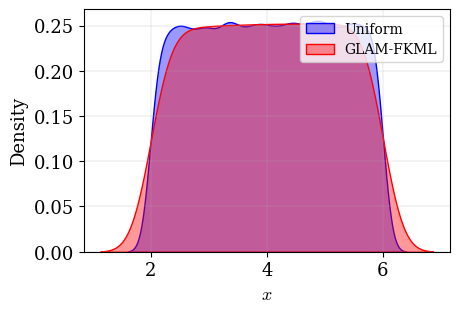

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
data = {
            'x': x,
            'y': y
        }
### Figure name and DPI
dpi = 600                                                                               # Change as you wish
name = 'kde_histogram_compare' # Change as you wish

### Chart dimensions (in centimeters)
b_cm = 12                                                   # Change as you wish
h_cm = 8                                                    # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels (For LateX font format use the dollar sign $)
label_y = 'Density'
label_x = '$x$'                     # Change as you wish     
size_label = 13                     # Change as you wish
color_label = 'black'               # or hexadecimal. Change as you wish
size_axis = 13                      # Change as you wish
color_axis = 'black'                # or hexadecimal. Change as you wish

### Color KDE
color = ['blue', 'red']             # or hexadecimal. Change as you wish
alpha = 0.4                         # Change as you wish

### Legend. Do you need legend? Use the cell bellow:
legend_label = ['Uniform', 'GLAM-FKML']    # Change as you wish
size_legend = 10                       # Change as you wish
location_legend = 'upper right'       # Change as you wish

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

### Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)

### Plot with legend
sns.kdeplot(data=data, x='x', fill=True, alpha=alpha, ax=ax, color=color[0], label=legend_label[0])
sns.kdeplot(data=data, x='y', fill=True, alpha=alpha, ax=ax, color=color[1], label=legend_label[1])
### Legend. Do you need legend? Use the cell bellow:
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()